# 04a — Conditional, calibrated DI-VAR

CDI-VAR keeps the fitted VAR as the interpretable conditional mean. Its diffusion model generates standardized joint innovations conditional on five recent standardized residuals and the current EWMA volatility state. Training, checkpoint validation, and forecast calibration use three non-overlapping chronological portions of the calibration period. Calibration is fitted from genuine rolling VAR forecasts and their realized lead-1, lead-5, and lead-20 outcomes—not from future one-step residuals.

The stored `calibration_multipliers` make the post-hoc adjustment inspectable: values above one widen the final VAR forecast distribution at that lead; values below one sharpen it. Calibration is isolated from the latent recursion: EWMA volatility and residual context are updated using raw conditional draws, and the scale adjustment is applied only after those innovations have propagated through the VAR.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
CACHE = ROOT / 'results/notebook_cache'
CACHE.mkdir(parents=True, exist_ok=True)
import matplotlib.pyplot as plt

from innovcal.api.innovations import fit_innovations, sample_innovations
from innovcal.forecasting.monte_carlo import simulate_forecast_paths
from innovcal.cdi_var.calibration import (
    apply_forecast_calibration,
    fit_rolling_var_forecast_calibration,
)
from innovcal.forecasting.rolling import generate_rolling_var_forecasts

In [2]:
EPOCHS = 300
returns = pd.read_csv(ROOT / 'data/processed/financial_returns.csv', index_col=0).to_numpy()
split = np.load(CACHE / 'financial_split.npz')
var_data = np.load(CACHE / 'fitted_var.npz')
fitted_var = {
    'beta': var_data['beta'],
    'lags': int(var_data['lags']),
    'include_intercept': True,
}

cdi_model = fit_innovations(
    var_data['residuals'],
    method='cdi_var',
    context_lags=5,
    volatility_span=60,
    validation_fraction=0.15,
    calibration_fraction=0.15,
    calibration_horizons=(1, 5, 20),
    calibration_paths=32,
    timesteps=50,
    epochs=EPOCHS,
    hidden_dim=128,
    time_embedding_dim=32,
    batch_size=64,
    early_stopping_patience=40,
    seed=123,
    verbose=True,
)

calibration_series = np.vstack([split['train'], split['calibration']])
fit_rolling_var_forecast_calibration(
    cdi_model,
    calibration_series,
    var_data['residuals'],
    initial_window=len(split['train']),
    lags=fitted_var['lags'],
    horizons=(1, 5, 20),
    n_paths=32,
    seed=123,
)

history = cdi_model['history']
print('Best epoch:', history['best_epoch'])
print('Raw calibration anchors:', cdi_model['raw_calibration_anchor_multipliers'])
print('Regularized calibration anchors:', cdi_model['calibration_anchor_multipliers'])
print('Deployed multipliers at leads 1, 5, and 20:',
      cdi_model['calibration_multipliers'][[0, 4, 19]])

Epoch 0001 | loss = 0.998421 | val = 0.981346
Epoch 0025 | loss = 0.847175 | val = 0.829782
Epoch 0050 | loss = 0.824532 | val = 0.842707


/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/vector_ar/fit.py:63: RuntimeWarning: divide by zero encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/vector_ar/fit.py:63: RuntimeWarning: overflow encountered in matmul
  fitted = X @ beta
/Users/jonathanma/Desktop/Projects/innovative-droBVAR/src/innovcal/vector_ar/fit.py:63: RuntimeWarning: invalid value encountered in matmul
  fitted = X @ beta


Best epoch: 20
Raw calibration anchors: {1: 1.06, 5: 1.06, 20: 1.67}
Regularized calibration anchors: {1: 1.03, 5: 1.03, 20: 1.25}
Deployed multipliers at leads 1, 5, and 20: [1.03 1.03 1.25]


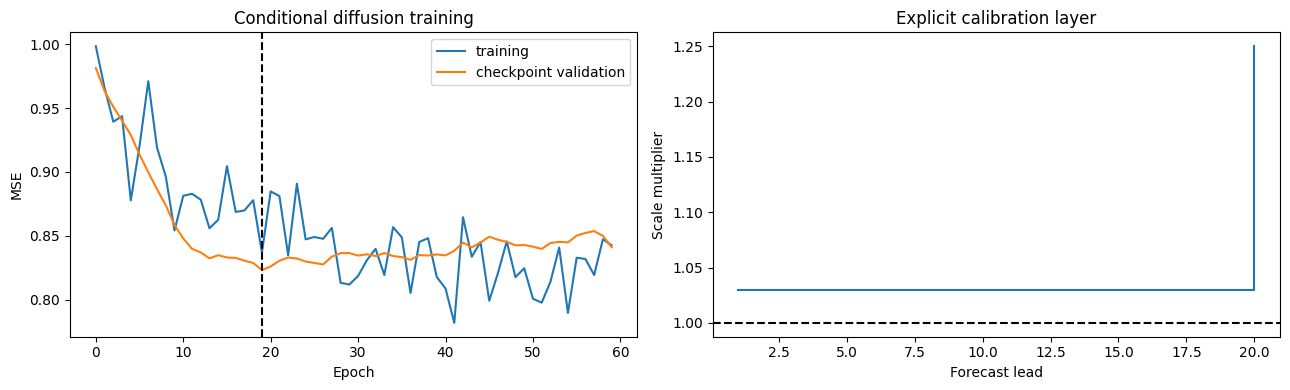

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['loss'], label='training')
axes[0].plot(history['validation_loss'], label='checkpoint validation')
axes[0].axvline(history['best_epoch'] - 1, color='black', linestyle='--')
axes[0].set(title='Conditional diffusion training', xlabel='Epoch', ylabel='MSE')
axes[0].legend()
axes[1].step(np.arange(1, len(cdi_model['calibration_multipliers']) + 1),
             cdi_model['calibration_multipliers'], where='post')
axes[1].axhline(1, color='black', linestyle='--')
axes[1].set(title='Explicit calibration layer', xlabel='Forecast lead', ylabel='Scale multiplier')
plt.tight_layout()
plt.show()

In [4]:
# A 20-day nominal forecast is sufficient for the common stress experiment.
history_values = calibration_series
innovations = sample_innovations(cdi_model, n_paths=250, horizon=20, seed=123)
forecast_paths = simulate_forecast_paths(
    history_values[-fitted_var['lags']:], fitted_var['beta'], innovations,
    fitted_var['lags'], fitted_var['include_intercept'],
)
forecast_paths = apply_forecast_calibration(
    forecast_paths, cdi_model['calibration_multipliers']
)
np.savez(
    CACHE / 'forecast_cdi_var.npz',
    forecast_paths=forecast_paths,
    innovation_paths=innovations,
    innovation_model='cdi_var',
)

test_start = len(split['train']) + len(split['calibration'])
rolling = generate_rolling_var_forecasts(
    returns,
    test_start=test_start,
    innovation_models={'cdi_var': cdi_model},
    horizon=20,
    n_paths=250,
    lags=fitted_var['lags'],
    origin_step=20,
    seed=123,
)
np.savez(
    CACHE / 'rolling_cdi_var.npz',
    forecasts=rolling.forecasts['cdi_var'],
    observations=rolling.observations,
    origins=rolling.origins,
    calibration_multipliers=rolling.calibration_history['cdi_var'],
)
print(f'Saved CDI-VAR forecasts at {len(rolling.origins)} rolling origins.')

Saved CDI-VAR forecasts at 47 rolling origins.
